# Finance Time Series 데이터 활용하기

## 1. 추세 판단 분류기 만들기

① 추세(Trend)와 데이터
- 추세란 일정한 방향으로 나아가려는 것, 주식에서 상승 혹은 하락 혹은 꾸준히 유지되는 것
- 추세(Trend)와 모멘텀(Momentum)의 차이
- 업비트(Upbit)의 이더리움 분봉 데이터
- 지도학습 기반의 이진 분류기(binary classification)

② 환경구성
- 필요 패키지 설치
- 데이터 불러오기

### 추세, Trend란?

- 상승 모멘텀이 부족하다, 추세가 꺾였다.. 라는 말에서 모멘텀은 뭐고 추세는 뭘까?
- 추세는 주가 또는 코인의 가격이 상승 혹은 하락에 관계없이 일정한 방향으로 일정 기간동안 꾸준히 유지되는 것
- 추세의 반대, 어느쪽으로 움직이지 않고 정체되어 있는 상태는 **보합**이라고 한다.
- 금융시장에서는 가격의 방향성이 끊임없이 변화 -> 투자 성공은 시장의 방향성 파악이 무엇보다 중요하다.
- 모멘텀도 추세와 유사한 의미. 모멘텀은 추세를 판단 가능한 지표로 상승 또는 하락의 추세가 유지되는 동력
- 추세와 모멘텀은 어떻게 보면 유사하다. (여기서도 유사한 의미로 본다.)


### 추세를 어떻게 알까?

- 모멘텀 및 추세를 미리 파악하기 위해 많은 지표가 사용되고, 만들어졌다.
- 여기서는 머신러닝을 활용해 추세 판단(모멘텀 포착)을 할 수 있는지 알아보았다.

### 활용 데이터 

- 국내 최대 암호화폐 거래소 중 하나인 Upbit 에서 다운로드 받은 **이더리움**의 분봉을 사용하여, 분류기를 개발
- 이더리움은 **2017-00-00 ~ 2019-00-00**까지 분봉을 사용

### 분류기 개발

- 지도학습 기반 분류기 개발
- 상승 : 1 / 하락 : 0 으로 라벨링
- RandomForest 기반 Bagging 분류기 생성


<Axes: xlabel='time'>

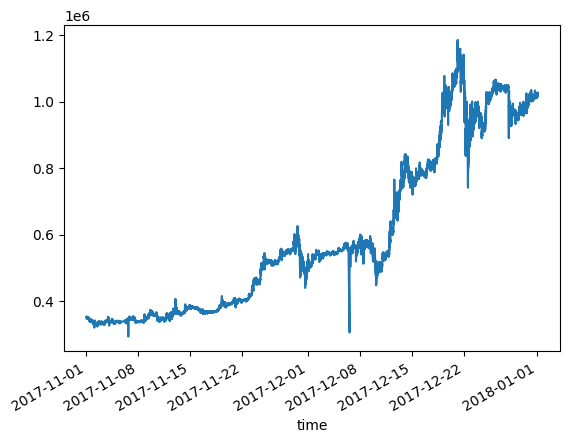

In [31]:
# Package Import

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Data Loading
modify_data = pd.read_csv(('/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Data/sub_upbit_eth_min_tick.csv'), index_col=0, parse_dates=True)
modify_data.loc['2017-11-01':'2017-12-31','close'].plot()


## Data Labeling

① 데이터 라벨링
- 추세(Trend)를 Labeling하는 4가지 방법

### Price Change Direction

- 가장 단순한 방식, 현재 가격과 특정 영업일 이전의 가격 차이로 라벨링하는 방식
- 간단하지만, 며칠 전 가격과 비교할 것인지에 따라 변동이 커질 수 있어 사용에 주의

$$ \text{Label} i(t) =
\begin{cases}
1, \quad \text{if price}_t - \text{price}_{t-n} > 0 \\
0, \quad \text{if else}  
\end{cases} $$

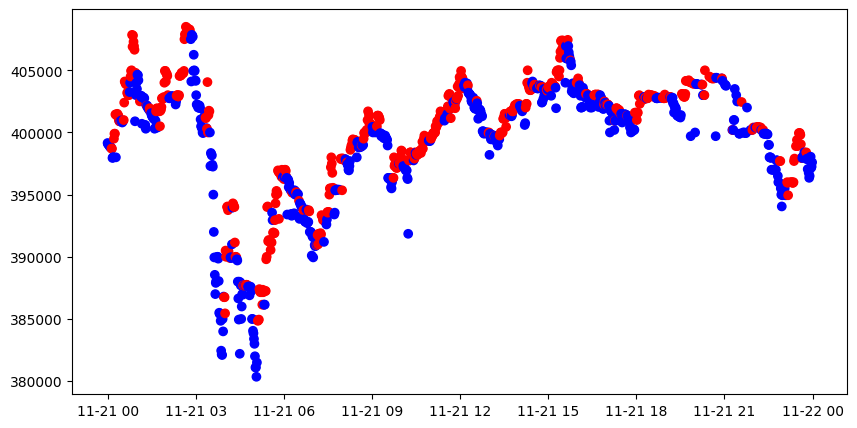

In [32]:
window = 10
momentum_signal = np.sign(np.sign(modify_data['close'] - modify_data['close'].shift(window)) + 1)
s_momentum_signal = pd.Series(momentum_signal, index=modify_data.index)

sub_data = modify_data.loc['2017-11-21', 'close']
c_sig = s_momentum_signal.loc['2017-11-21']
c_sig['color'] = np.where(c_sig == 1, 'red', 'blue')

plt.figure(figsize=(10,5))
plt.scatter(sub_data.index, sub_data, c=c_sig['color'])

### Using Moving Average

- 기술적 지표를 이용한 대표 방식
- 현재 주가가 특정 이동평균선에 있는지 없는지 여부로 라벨링
- 역시 간단하지만, 이전 방식과 마찬가지로 이동평균을 며칠로 할 것이냐를 결정하고, 이에 따라 Lag(지연) 발생

$$ \text{Label} i(t) =
\begin{cases}
1, \quad \text{if price}_t > \text{MA}(t \dots t-n) \\
0, \quad \text{if else}  
\end{cases} $$

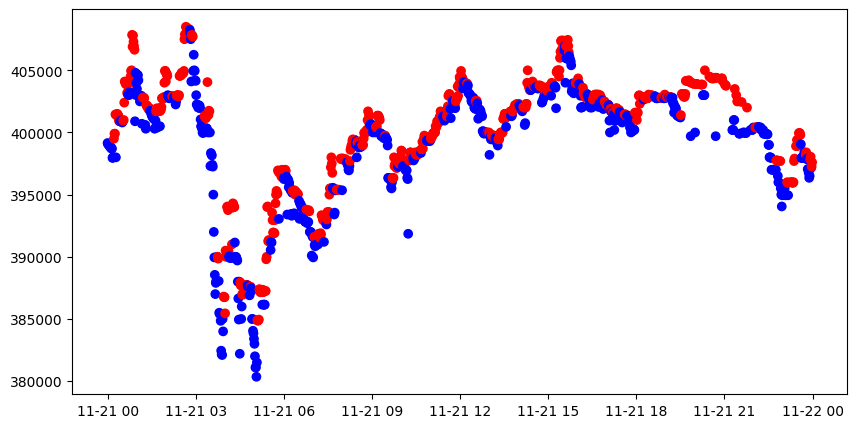

In [33]:
momentum_signal = np.sign(np.sign(modify_data['close'] - modify_data['close'].rolling(window).mean()) + 1)
s_momentum_signal = pd.Series(momentum_signal, index=modify_data.index)

sub_data = modify_data.loc['2017-11-21', 'close']
c_sig = s_momentum_signal.loc['2017-11-21']
c_sig['color'] = np.where(c_sig == 1, 'red', 'blue')

plt.figure(figsize=(10,5))
plt.scatter(sub_data.index, sub_data, c=c_sig['color'])

### Local Min-Max

- 국지적인 최소 / 최대값을 계속 갱신하며, 최소-최대 구간을 이어나가며 라벨링
- 핵심은 최소, 최대값을 갱신하다가, 서로 상대방 값으로 초기화
- 순차적인 가격 확인이 요구되는 만큼 데이터가 증가하면, 연산시간도 늘어나는 단점
- Wait 계수를 작게하면 변동성이 커질 수 있으므로, 신중하게 계수 선택

> Wait 계수 : 값이 반등하는게 잦으면, 라벨 전환이 너무 빠르니 전환 기준 횟수를 거는 필터 역할

In [34]:
# Local min / max 를 추출하기 위한 함수 (Pseudo-code)
def get_local_min_max(close, wait=3):
    min_value = close.iloc[0]
    max_value = close.iloc[0]
    n_cnt_min, n_cnt_max = 0, 0
    
    mins, maxes = [], []
    min_idxes, max_idxes = [], []
    b_min_update, b_max_update = False, False
    
    for idx, val in zip(close.index[1:], close.values[1:]):
        if val < min_value:
            min_value = val
            mins.append(min_value)
            min_idxes.append(idx)
            n_cnt_min = 0
            b_min_update = True
        if val > max_value:
            max_value = val
            maxes.append(max_value)
            max_idxes.append(idx)
            n_cnt_max = 0
            b_max_update = True
        
        if not b_max_update:
            b_min_update = False
            n_cnt_min += 1
            if n_cnt_min >= wait:
                max_value = min_value
                n_cnt_min = 0
    
        if not b_min_update:
            b_max_update = False
            n_cnt_max += 1
            if n_cnt_max >= wait:
                min_value = max_value
                n_cnt_max = 0
               
    return pd.DataFrame.from_dict({'min_time': min_idxes, 'local_min': mins}), pd.DataFrame.from_dict({'max_time': max_idxes, 'local_max': maxes})

In [35]:
mins, maxes = get_local_min_max(sub_data, wait=3)

(376546.5, 412585.0)

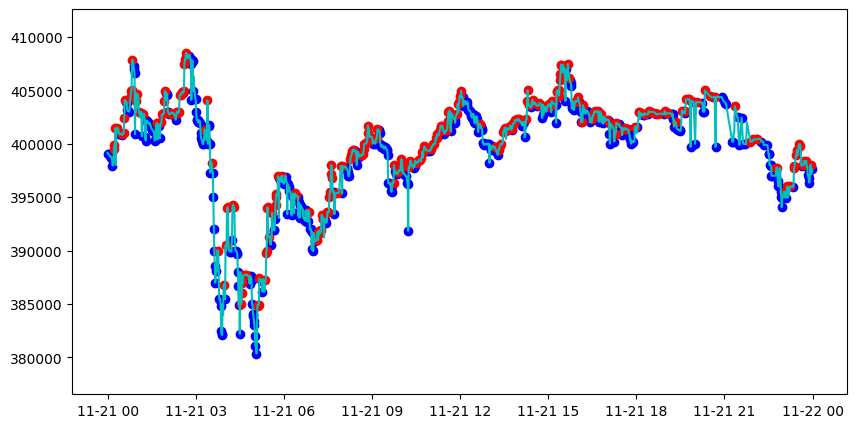

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(sub_data, 'c')
ax.scatter(mins.min_time, mins.local_min, c='blue')
ax.scatter(maxes.max_time, maxes.local_max, c='red')
ax.set_ylim([sub_data.min() * 0.99, sub_data.max()  * 1.01])

(376546.5, 412585.0)

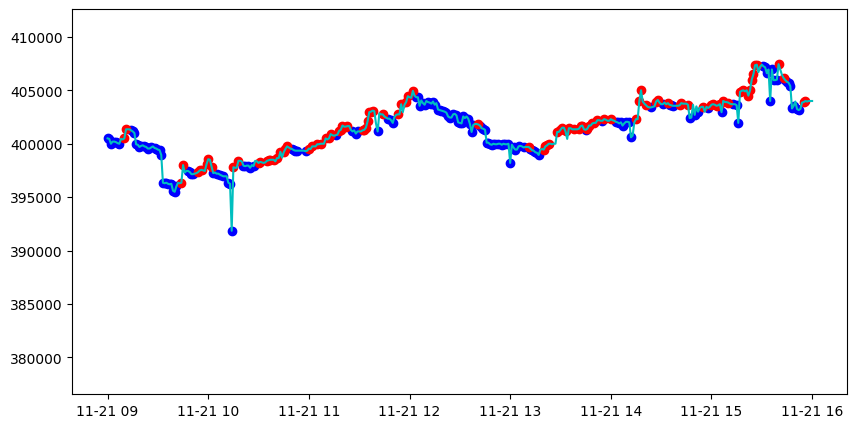

In [37]:
st_time, ed_time = '2017-11-21 09:00:00', '2017-11-21 16:00:00'

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(sub_data.loc[st_time:ed_time], 'c')
ax.scatter(mins.set_index('min_time', drop=False).min_time.loc[st_time:ed_time], mins.set_index('min_time').local_min.loc[st_time:ed_time], c='blue')
ax.scatter(maxes.set_index('max_time', drop=False).max_time.loc[st_time:ed_time], maxes.set_index('max_time').local_max.loc[st_time:ed_time], c='red')
ax.set_ylim([sub_data.min() * 0.99, sub_data.max()  * 1.01])

In [38]:
mins.shape[0], maxes.shape[0]

(477, 273)

### Trend Scanning

- Marcos Lopez de Prado 의 저서 'Machine Learning for Asset Managers'에 소개된 Labeling 방식
- 시계열 데이터 $x_t$가 주식 또는 코인의 가격일 때
    - 현재 시점 $t$ 에서 $t+l$ 시점까지의 회귀식을 피팅해 $\beta$ 값 구하기
    - 이 $\beta$ 값의 $t$값을 구하고
    - max $t$값의 부호를 통해 라벨링
- 하기 코드는 Hudson & Thames 가 공개한 MLFinLab 패키지의 코드를 활용했습니다.

In [39]:
def t_val_lin_r(close):
    import statsmodels.api as sml
    
    # t-value from a linear trend
    x = np.ones((close.shape[0], 2))
    x[:, 1] = np.arange(close.shape[0])
    ols = sml.OLS(close, x).fit()
    return ols.tvalues[1]

In [40]:
look_forward_window = 60
min_sample_length = 5
step = 1
t1_array = []
t_values_array = []

In [41]:
# 이 코드 블럭은 실행에 20~30분정도 걸립니다.

molecule = modify_data['2017-11-01':'2017-11-30'].index
label = pd.DataFrame(index=molecule, columns=['t1', 't_val', 'bin'])
tmp_out = []

for ind in tqdm(molecule):
    subset = modify_data.loc[ind:, 'close'].iloc[:look_forward_window]  # 전방 탐색을 위한 샘플 추출
    if look_forward_window > subset.shape[0]:
        continue
    
    tmp_subset = pd.Series(index=subset.index[min_sample_length-1:subset.shape[0]-1])
    tval = []

    # 회귀분석을 통해 t 통계량값을 이용하여 추세 추정
    for forward_window in np.arange(min_sample_length, subset.shape[0]):
        df = subset.iloc[:forward_window]
        tval.append(t_val_lin_r(df.values))
    
    tmp_subset.loc[tmp_subset.index] = np.array(tval)
    idx_max = tmp_subset.replace([-np.inf, np.inf, np.nan], 0).abs().idxmax()
    tmp_t_val = tmp_subset[idx_max]
    tmp_out.append([tmp_subset.index[-1], tmp_t_val, np.sign(tmp_t_val)])

label.loc[molecule] = np.array(tmp_out)  # prevent leakage

label['t1'] = pd.to_datetime(label['t1'])
label['bin'] = pd.to_numeric(label['bin'], downcast='signed')

100%|██████████| 33384/33384 [02:49<00:00, 196.86it/s]


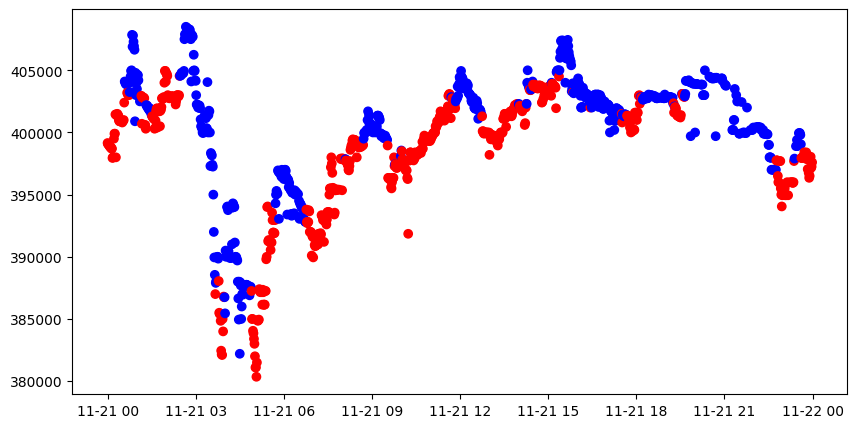

In [42]:
sub_data = modify_data.loc['2017-11-21', 'close']
c_sig = label['bin'].loc['2017-11-21']
c_sig['color'] = np.where(c_sig == 1, 'red', 'blue')

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(sub_data.index, sub_data.values,
              c=c_sig['color'])

## Feature Engineering

- 도메인 지식을 활용해 정제되지 않은 Raw Data를 탐색-분석-가공을 거쳐 특성을 추출하고 선택하는 것

① 환경구성 및 데이터 불러오기
- 필요 패키지 설치
- 데이터 불러오기

② Technical Index
- 기존 데이터셋(시가, 고가, 저가, 종가, 거래량)에서 기술적 지표(추세, 변동성, 거래량, 모멘텀)를 적용한 데이터셋 만들기
- 새로 만든 데이터셋에서 활용하고자 하는 시점에 대한 수익률, 변화율, 변동성을 적용

③ Feature Selection methods
- 특성추출(Feature Extraction)과 특성선택(Feature Selection) 중 특성선택을 하는 방법으로 접근하여 어떤 방법론이 있는지 확인

- 분류기의 성능 개선을 위해 중요한 것은 적절한 Feature 선택
- 3가지 선택 방식
    - Fliter Method : Feature간 연관성을 찾는 방식(information gain, correlation coefficient 등)
    - Wrapper Method : 해결하고자 하는 문제에 대한 유용성을 측정하는 방식. Validation set에서의 성능이 최대화되는 Feature Set을 선정 (Recursive Feature Elimination, Sequential Feature Selection 등)
    - Embedded Method : 훈련의 알고리즘에 Feature 선정과정이 포함되는 방식(Lasso, Ridge, Elastic Net 등)
- 이 중 Wrapper Method 방식을 다루어보고 Prodo 의 저서 'Advances in Financial ML'에서 소개된 방식도 적용
- 주가 모멘텀 포착을 위해 사용할 수 있는 Feature는 무엇이 있고, 어떤 것을 선정해야 하는가?
- SHAP 패키지를 통해서도 Feature Importance 확인

In [43]:
# !pip install ta==0.9.0
# !pip install shap==0.41.0

### 환경 구성 및 데이터 불러오기

ta, shap 라이브러리 사용

- ta : Python Pandas 기반 금융 시계열 데이터 분석 라이브러리
- shap : Shapley Additive explanations 뒤에서 설명

In [1]:
import datetime
import sys
import os
import re
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

from FTS.feature_importance import importance as imp
from sklearn.feature_selection import SequentialFeatureSelector, RFECV

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier

In [2]:
df_modify_data = pd.read_csv('/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Data/sub_upbit_eth_min_tick.csv', index_col=0, parse_dates=True)
df_label_data = pd.read_pickle('/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Data/sub_upbit_eth_min_feature_labels.pkl')
df_sub_modify_data = df_modify_data.loc[df_label_data.index]

# 학습 시간 단축을 위해 여기선 편의상 1000개의 데이터만 가져옵니다.
df_sub_modify_data = df_sub_modify_data.iloc[:1000]

In [3]:
df_sub_modify_data.head()

,open,high,low,close,volume
time,,,,,
2018-01-01 00:43:00,1017500,1019000,1017500,1018500,30.272135
2018-01-01 00:44:00,1018500,1021500,1018000,1021500,25.131162
2018-01-01 00:45:00,1021500,1022000,1020000,1020000,17.108609
2018-01-01 00:46:00,1020000,1025000,1019000,1025000,44.289130
2018-01-01 00:47:00,1020000,1020000,1019000,1019000,10.224255


In [4]:
df_label_data.head(), df_label_data.tail()

(                        open     high      low    close     volume  \
 time                                                                 
 2018-01-01 00:43:00  1017500  1019000  1017500  1018500  30.272135   
 2018-01-01 00:44:00  1018500  1021500  1018000  1021500  25.131162   
 2018-01-01 00:45:00  1021500  1022000  1020000  1020000  17.108609   
 2018-01-01 00:46:00  1020000  1025000  1019000  1025000  44.289130   
 2018-01-01 00:47:00  1020000  1020000  1019000  1019000  10.224255   
 
                      volume_cmf     volume_fi  volume_mfi  volume_sma_em  \
 time                                                                       
 2018-01-01 00:43:00    0.363435    719.550725   56.072055   8.940793e+11   
 2018-01-01 00:44:00    0.368141  10053.792799   54.776628   2.480511e+12   
 2018-01-01 00:45:00    0.365340   5589.204549   56.034287   3.376449e+12   
 2018-01-01 00:46:00    0.358534  32571.260299   50.196394   2.908715e+12   
 2018-01-01 00:47:00    0.327429  20831

In [5]:
df_label_data.value_counts()

open     high     low      close    volume       volume_cmf  volume_fi      volume_mfi  volume_sma_em  volume_vpt  volatility_atr  volatility_ui  trend_macd_diff  trend_adx  trend_trix  trend_mass_index  trend_dpo  trend_aroon_ind  momentum_rsi  momentum_wr  vol_change_5  ret_5      vol_change_10  ret_10     vol_change_20  ret_20     std_30        vol_std_30  t_value
92470    92520    92470    92510    23.784737    -0.406112   -4.468977e+03  33.347525   -3.270934e+09  -0.034910   120.840686      0.543619       -1.057488        24.426699  -0.023704   25.312447         -214.0     -75.0            38.868682     -88.461538    1.897454     -0.000540  -0.806454      -0.001942   0.102881      -0.007084  246.316040    62.167032    1.0       1
402750   403350   402750   403350   12.718230     0.041128    1.230674e+03  51.711776    9.754633e+11   0.014162   335.209225      0.109884        113.913488      51.160701   0.005403   24.324499         -727.5      85.0            62.266872     -0.000000

## Techinical Index

① 기술적 지표
- 아래 여러 지표들을 기존의 데이터셋에 추가하는 과정

② 수익률 / 변동성 지표
- 여러 지표들이 추가된 데이터셋에서 활용하고자 하는 시점에 수익률과 변동성 적용

Feature Selection을 하기 위한 선행과정으로 수익률 / 변동성까지 적용된 데이터셋을 표준화(standardization)하고 fit_transform하여 RandomForest에 적용

### 기술적 지표란?

- 시장의 주가 또는 거래량 데이터를 기반으로 주가의 향방을 예측하기 위해 고안된 지표

1. 추세 지표 
    - MACD (Moving Average Convergence/Divergence) : 단기 이평선과 장기 이평선의 차이로 주가의 수렴 / 확산 정도를 나타내는 지표, 'signal', 'average', 'diverence'로 구성됨.
    - ADX (Average Directional Movement) : 금일의 주가 움직임의 범위가 전일의 범위를 어느 방향으로 벗어났는지를 관찰, 추세의 강도를 추적하는 지표
    - TRIX (Triple Exponential) : n-영업일 지수가중평균을 3번 연달아 실시한 후, 그 값의 기울기를 나타낸 지표
    - DPO (detrended price oscillator) : 가장 최신의 가격 흐름에 반응하지 않도록 변위된 이동평균을 사용하여, 장기추세를 제거하기 위한 지표. 중기 과매수 / 과매도 정도를 표시
    - AROON : 추세의 강도와 변화를 식별하기 위한 지표, 고가사이의 시간차와 저가사이의 시간차를 측정

2. 변동성 지표
    - TR (Average True Range) : 시장의 변동성을 측정하기 위한 지표, (고가 - 저가), (고가 - 전일종가)의 절대값, (저가 - 전일종가)의 절대값 중 큰값을 취하여, 이동평균
    - UI (Ulcer Index) : 가격 하락의 유지기간, 깊이를 통해 가격의 하락 위험을 측정하는 지표

3. 거래량 지표
    - CMF (Chaikin Money Flow) : 산출방식이 MACD와 유사, 두 accumulation/distribution line의 EMA값의 차이를 통해 돈의 유입/유출을 파악하려는 지표
    - MFI (Money Flow Index) : 가격의 흐름과 거래량의 조합으로 모멘텀의 방향성을 나타내는 지표
    - FI (Force Index) : 가격과 거래량을 사용하여 가격의 움직임을 좌우하는 힘의 강도를 측정하는 지표
    - SMA EM (Ease of Movement) : 가격의 상승/하락을 판단하기 위한 지표. 가격의 변동성과 거래량을 통해 가격 흐름의 용이성을 측정
    - VPT (Volume Price Trend) : 가격의 변화 강도와 그 방향을 나타내는 지표. 수요 / 공급의 균형을 측정

4. 모멘텀 지표
    - RSI (Relative Strength Index) : 가격 흐름의 상대강도를 측정하는 지표. 일정기간 내의 평균 수익과 손실의 강도를 비교함.
    - WR (Williams %R) : 과매도 / 과매수를 측정하는 지표(-100 ~ 0). 진입 / 청산 시점을 포착하는데 사용됨.

TA 패키지로 각 지표 산출

In [6]:
mt = 1
fillna = False
df_ = df_sub_modify_data.copy()
open, high, low, close, volume = 'open', 'high', 'low', 'close', 'volume'
cols = [open, high, low, close, volume]

## Volume Index
# Chaikin Money Flow
df_["volume_cmf"] = ta.volume.ChaikinMoneyFlowIndicator(
                        high=df_[high], low=df_[low], close=df_[close], volume=df_[volume], window=20*mt, fillna=fillna
                    ).chaikin_money_flow()
# Force Index
df_["volume_fi"] = ta.volume.ForceIndexIndicator(
                        close=df_[close], volume=df_[volume], window=15*mt, fillna=fillna
                    ).force_index()
# Money Flow Indicator
df_["volume_mfi"] = ta.volume.MFIIndicator(
                        high=df_[high],
                        low=df_[low],
                        close=df_[close],
                        volume=df_[volume],
                        window=15*mt,
                        fillna=fillna,
                    ).money_flow_index()
# Ease of Movement
df_["volume_sma_em"] = ta.volume.EaseOfMovementIndicator(
                            high=df_[high], low=df_[low], volume=df_[volume], window=15*mt, fillna=fillna
                        ).sma_ease_of_movement()

# Volume Price Trend
df_["volume_vpt"] = ta.volume.VolumePriceTrendIndicator(
                        close=df_[close], volume=df_[volume], fillna=fillna
                    ).volume_price_trend()

## volatility index
# Average True Range
df_["volatility_atr"] = ta.volatility.AverageTrueRange(
                            close=df_[close], high=df_[high], low=df_[low], window=10*mt, fillna=fillna
                        ).average_true_range()

# Ulcer Index
df_["volatility_ui"] = ta.volatility.UlcerIndex(
                            close=df_[close], window=15*mt, fillna=fillna
                        ).ulcer_index()

## trend index
# MACD
df_["trend_macd_diff"] = ta.trend.MACD(
                            close=df_[close], window_slow=25*mt, window_fast=10*mt, window_sign=9, fillna=fillna
                        ).macd_diff()

# Average Directional Movement Index (ADX)
df_["trend_adx"] = ta.trend.ADXIndicator(
                        high=df_[high], low=df_[low], close=df_[close], window=15*mt, fillna=fillna
                    ).adx()

# TRIX Indicator
df_["trend_trix"] = ta.trend.TRIXIndicator(
                        close=df_[close], window=15*mt, fillna=fillna
                    ).trix()

# Mass Index
df_["trend_mass_index"] = ta.trend.MassIndex(
                            high=df_[high], low=df_[low], window_fast=10*mt, window_slow=25*mt, fillna=fillna
                        ).mass_index()

# DPO Indicator
df_["trend_dpo"] = ta.trend.DPOIndicator(
                        close=df_[close], window=20*mt, fillna=fillna
                    ).dpo()

# Aroon Indicator
df_["trend_aroon_ind"] = ta.trend.AroonIndicator(close=df_[close], window=20, fillna=fillna).aroon_indicator()

## momentum index
# Relative Strength Index (RSI)
df_["momentum_rsi"] = ta.momentum.RSIIndicator(close=df_[close], window=15*mt, fillna=fillna).rsi()

# Williams R Indicator
df_["momentum_wr"] = ta.momentum.WilliamsRIndicator(
                        high=df_[high], low=df_[low], close=df_[close], lbp=15*mt, fillna=fillna
                    ).williams_r()

/Users/chankyulee/Library/Python/3.9/lib/python/site-packages/ta/trend.py:769: RuntimeWarning: invalid value encountered in scalar divide
  dip[idx] = 100 * (self._dip[idx] / value)
/Users/chankyulee/Library/Python/3.9/lib/python/site-packages/ta/trend.py:774: RuntimeWarning: invalid value encountered in scalar divide
  din[idx] = 100 * (self._din[idx] / value)


In [7]:
# 결과 확인
df_

,open,high,low,close,volume,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,volatility_atr,volatility_ui,trend_macd_diff,trend_adx,trend_trix,trend_mass_index,trend_dpo,trend_aroon_ind,momentum_rsi,momentum_wr
time,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:43:00,1017500,1019000,1017500,1018500,30.272135,NaN,NaN,NaN,NaN,-0.889013,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:44:00,1018500,1021500,1018000,1021500,25.131162,NaN,NaN,NaN,NaN,-0.820151,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:45:00,1021500,1022000,1020000,1020000,17.108609,NaN,NaN,NaN,NaN,0.048901,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:46:00,1020000,1025000,1019000,1025000,44.289130,NaN,NaN,NaN,NaN,0.191981,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:47:00,1020000,1020000,1019000,1019000,10.224255,NaN,NaN,NaN,NaN,0.157254,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 17:18:00,1053000,1054000,1053000,1054000,4.617338,0.363791,268.138329,28.040953,3.453289e+13,0.023786,2458.595897,0.369276,208.065857,22.331986,0.001698,26.468536,-175.0,-5.0,54.092986,-14.285714
2018-01-01 17:19:00,1054000,1054000,1053500,1053500,0.854595,0.328862,181.208821,26.097996,1.915277e+13,0.003980,2262.736307,0.327488,197.330634,20.851177,0.002242,26.113270,-350.0,-5.0,52.722343,-21.428571
2018-01-01 17:20:00,1053500,1054000,1053500,1053500,39.424203,0.110152,158.557718,23.589422,1.376033e+13,-0.000405,2086.462676,0.319410,176.451252,19.469088,0.002759,25.183995,-2250.0,-5.0,52.722343,-21.428571


### 수익률 / 변동성 지표


- 수익률, 변화율 지표
    - 현재가격(종가)과 직전 n-영업일 가격과의 비율 : $ R_t = \frac {\text{close}_t}{\text{close}_{t-n}} - 1$
    - 금일 거래량과 직전 n-영업일 거래량과의 비율 : $ \text{Volume Change}_t = \frac {\text{volume}_t}{\text{volume}_{t-n}} - 1$

- 변동성 지표
    - 종가의 n-영업일 이동 표준편차
    - 거래량의 n-영업일 이동 표준편차


In [8]:
windows_mom = [5, 10, 20]
windows_std = [30]

for i in windows_mom:
    df_[f'vol_change_{i}'] = df_.volume.pct_change(i).round(6)
    df_[f'ret_{i}'] = df_.close.pct_change(i).round(6)

for i in windows_std:
    df_[f'std_{i}'] = df_.close.rolling(i).std()
    df_[f'vol_std_{i}'] = df_.volume.rolling(i).std()

In [9]:
# 결과 확인
df_

,open,high,low,close,volume,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,...,momentum_rsi,momentum_wr,vol_change_5,ret_5,vol_change_10,ret_10,vol_change_20,ret_20,std_30,vol_std_30
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:43:00,1017500,1019000,1017500,1018500,30.272135,NaN,NaN,NaN,NaN,-0.889013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:44:00,1018500,1021500,1018000,1021500,25.131162,NaN,NaN,NaN,NaN,-0.820151,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:45:00,1021500,1022000,1020000,1020000,17.108609,NaN,NaN,NaN,NaN,0.048901,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:46:00,1020000,1025000,1019000,1025000,44.289130,NaN,NaN,NaN,NaN,0.191981,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:47:00,1020000,1020000,1019000,1019000,10.224255,NaN,NaN,NaN,NaN,0.157254,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 17:18:00,1053000,1054000,1053000,1054000,4.617338,0.363791,268.138329,28.040953,3.453289e+13,0.023786,...,54.092986,-14.285714,-0.415503,0.000000,3.099664,0.001901,-0.784387,0.004766,2323.357163,18.362018
2018-01-01 17:19:00,1054000,1054000,1053500,1053500,0.854595,0.328862,181.208821,26.097996,1.915277e+13,0.003980,...,52.722343,-21.428571,-0.756619,0.000475,-0.980701,0.003333,-0.918695,0.003333,2323.357163,18.477804
2018-01-01 17:20:00,1053500,1054000,1053500,1053500,39.424203,0.110152,158.557718,23.589422,1.376033e+13,-0.000405,...,52.722343,-21.428571,2.048467,0.000475,2.818777,0.001426,5.492889,-0.001895,2323.357163,19.049121


In [11]:
overlap_cols = df_.columns.intersection(df_label_data.columns)
df_tmp_data = df_.join(df_label_data.drop(columns=overlap_cols)).dropna()
X, y = df_tmp_data.iloc[:, 5:-1], df_tmp_data.iloc[:, -1]

sc = StandardScaler()
X_sc = sc.fit_transform(X)
X_sc = pd.DataFrame(X_sc, index=X.index, columns=X.columns)

In [13]:
X_sc.head()

,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,volatility_atr,volatility_ui,trend_macd_diff,trend_adx,trend_trix,...,momentum_rsi,momentum_wr,vol_change_5,ret_5,vol_change_10,ret_10,vol_change_20,ret_20,std_30,vol_std_30
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 01:26:00,-1.668089,0.413139,1.295769,0.298186,-0.094900,-0.159127,-0.870192,0.038574,1.481133,0.831971,...,0.808557,0.638000,-0.304687,0.262587,-0.355701,0.616631,-0.357774,0.394948,-0.342360,-0.144448
2018-01-01 01:27:00,-1.424909,0.256599,1.195268,0.007494,-0.204721,-0.181539,-0.771454,-0.372325,1.318230,0.826698,...,0.000685,-1.155760,-0.307967,-1.100148,-0.358039,-0.062666,-0.376163,0.071495,-0.390223,-0.108063
2018-01-01 01:28:00,-1.408074,0.245020,1.010128,-0.061970,-0.113751,-0.389976,-0.711847,-0.557438,1.166187,0.804052,...,0.168418,-0.829622,-0.258667,-0.495423,-0.346543,0.050357,-0.208705,-0.009575,-0.411974,-0.141673
2018-01-01 01:29:00,-1.134051,0.188990,0.880307,-0.089462,-0.003930,-0.577569,-0.651612,-0.664890,1.024280,0.768894,...,0.168418,-0.829622,-0.199056,-0.646838,-0.179455,-0.175689,0.362904,0.152234,-0.438134,-0.148397
2018-01-01 01:30:00,-1.013530,0.090638,0.664374,-0.180660,-0.135703,-0.620892,-0.578042,-0.788550,0.821615,0.720309,...,-0.037171,-1.155760,-0.155261,-0.798253,-0.378831,-0.288712,-0.028537,0.395943,-0.486916,-0.161094


In [14]:
rfc = RandomForestClassifier(class_weight='balanced')
rfc.fit(X_sc, y)

RandomForestClassifier(class_weight='balanced')

## Feature Selection methods

### Feature Selection

- MDI, Mean Decrease Impurity : Tree 계열 분류기에서 산출되는 Feature Importance 값을 사용한 Feature Selection 기법
    - In-Sample 방식 --> Train Set의 정확도를 기반으로 하기 때문에 In-Sample 이라고 한다
    - 모든 Feature가 어느 정도의 중요도를 가짐 
    - 모든 Feature Importance 의 총합은 1
    - substitution effect를 해결하지 못함

In [15]:
feat_imp = imp.mean_decrease_impurity(rfc, X.columns)

In [16]:
feat_imp

,mean,std
volume_cmf,0.045548,0.002017
volume_fi,0.043374,0.002413
volume_mfi,0.049042,0.002400
volume_sma_em,0.046483,0.002112
volume_vpt,0.024977,0.001583
volatility_atr,0.061249,0.002888
volatility_ui,0.051649,0.002673
trend_macd_diff,0.080825,0.003800
trend_adx,0.055137,0.002717
trend_trix,0.064146,0.002905


- MDA, Mean Decrease Accuracy : Tree 외의의 분류기에서도 사용가능한 Feature Selection 기법

    - OOS(Out-of-Sample) 방식 --> Test Set을 기준으로 정확도를 산출하는 방식이기 때문에 OOS 라고 칭합니다.
    - Accuracy 이외의 다른 성능지표를 사용할 수 있습니다.
    - MDI와 마차가지로 substitution effect에서 자유롭지 못 합니다.
    - MDI와 달리, 모든 Feature가 중요하다고 나오지 않을 수 있습니다. 

- 연산 절차
    - 분류기를 Fitting합니다.
    - 성능지표에 따라 OOS 성능을 측정합니다.
    - 순차적으로 각 Feature 에 대해서, 무작위로 섞은 후 OOS 성능을 기존값과 비교하는 작업을 전체 Feature에 대해 수행합니다.

In [21]:
svc_rbf = SVC(kernel='rbf', probability=True)
cv = KFold(n_splits=5)
feat_imp_mda = imp.mean_decrease_accuracy(svc_rbf, X_sc, y, cv_gen=cv)

/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/FTS/feature_importance/importance.py:164: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  importance.replace([-np.inf, np.nan], 0, inplace=True)  # Replace infinite values


In [22]:
def plot_feature_importance(importance_df, save_fig=False, output_path=None):
    # Plot mean imp bars with std
    plt.figure(figsize=(10, importance_df.shape[0] / 5))
    importance_df.sort_values('mean', ascending=True, inplace=True)
    importance_df['mean'].plot(kind='barh', color='b', alpha=0.25, xerr=importance_df['std'], error_kw={'ecolor': 'r'})
    if save_fig:
        plt.savefig(output_path)
    else:
        plt.show()

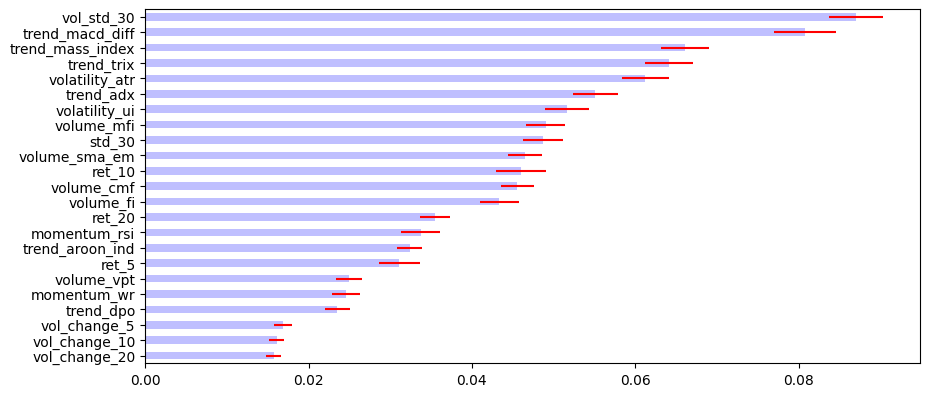

In [23]:
plot_feature_importance(feat_imp)

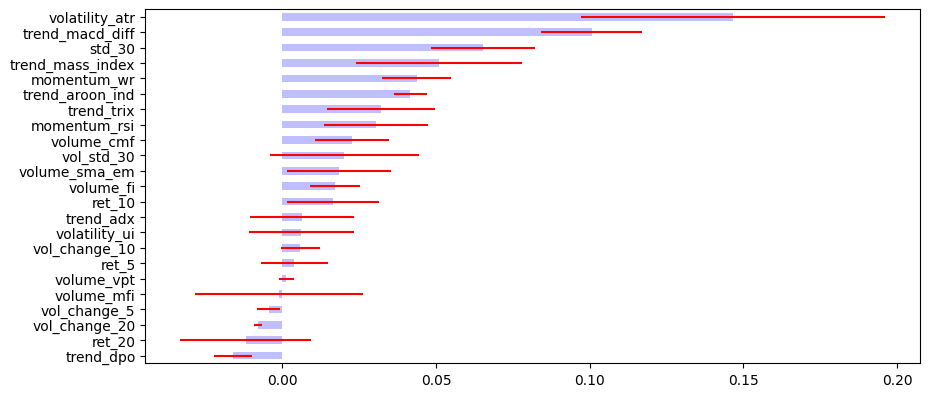

In [24]:
plot_feature_importance(feat_imp_mda)

### Sequential Feature Selection

- RFE CV (Recursive Feature Elimination)
    - Data Set을 K개로 분할하여 학습과 검증을 동시에 진행하며, 검증시 Feature의 기여도에 따라 삭제 여부를 결정하는 방식을 말합니다.
    - Validation 성능이 가장 좋은 Feature를 최종 Feature로 결정합니다.

In [25]:
svc_rbf = SVC(kernel='linear', probability=True)
rfe_cv = RFECV(svc_rbf, cv=cv)
rfe_fitted = rfe_cv.fit(X_sc, y)

In [26]:
rfe_df = pd.DataFrame([rfe_fitted.support_, rfe_fitted.ranking_], columns=X_sc.columns).T.rename(columns={0:"Optimal_Features", 1:"Ranking"})
rfe_df

,Optimal_Features,Ranking
volume_cmf,False,13
volume_fi,False,3
volume_mfi,False,10
volume_sma_em,True,1
volume_vpt,False,9
volatility_atr,True,1
volatility_ui,False,4
trend_macd_diff,True,1
trend_adx,False,11
trend_trix,False,5


In [27]:
rfe_df[rfe_df["Optimal_Features"]==True]

,Optimal_Features,Ranking
volume_sma_em,True,1
volatility_atr,True,1
trend_macd_diff,True,1
momentum_rsi,True,1
momentum_wr,True,1
std_30,True,1


- SFS (Sequential Feature Selection) : 순차적으로 Feature를 더하거나 빼는 방식으로 Feature의 최적조합을 찾는 방식입니다.
    - Backward / Forward 방식 모두 사용할 수 있습니다.
        - Forward: Null에서 시작하여, Feature를 하나씩 더해가는 방식으로 조합을 찾습니다.
        - Backwrd: 모든 Feature에서 시작하여 하나씩 빼가는 방식으로 조합을 찾습니다.

In [28]:
n = 2

sfs_forward = SequentialFeatureSelector(svc_rbf, n_features_to_select=n, direction='forward')
sfs_fitted = sfs_forward.fit(X_sc, y)

In [31]:
sfs_rank = sfs_fitted.get_support()
sfs_df = pd.DataFrame(sfs_rank, index=X_sc.columns, columns=["Optimal_Features"])

sfs_df [sfs_df ["Optimal_Features"]==True].index

Index(['volume_sma_em', 'trend_macd_diff'], dtype='object')

### SHAP (Shapley Additive explanations)

- 게임이론적인 접근방식을 통해 분류기의 출력을 설명하기 위한 기법

> Shapley Value : 게임이론에서 여러명의 플레이어에게 공정한 상벌을 배분하기 위한 솔루션으로써, 여러 플레이어의 공헌도는 서로 상이하지만, 상호간에 이득과 손실을 주고받는 상황에 적용되는 값. 게임 내에서 각 플레이어는 최대의 성과를 얻어내기 위한 의사결정을 연쇄적으로 수행하게 되며 그러한 과정을 통해 얻게 된 게임의 결과에서 해당 플레이어에게 기대할 수 있는 평균적인 한계 공헌도를 말한다.

In [33]:
import numpy as np
np.bool = bool  # 임시 패치

explainer = shap.TreeExplainer(rfc)
shap_value = explainer.shap_values(X_sc)

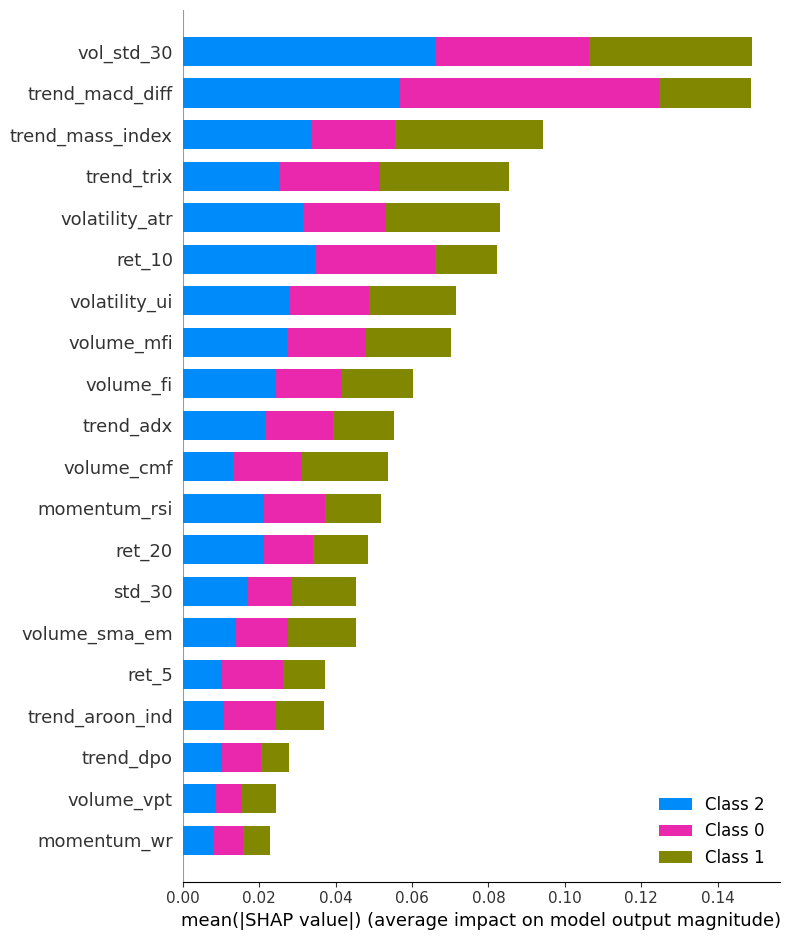

In [34]:
shap.summary_plot(shap_value, X_sc)

## Model Training

① 환경 구성
- 라이브러리 불러오기
- 데이터 불러오기

② Purged K-fold for Cross-Validation
- 기존의 Cross-Validation의 취약점인 Overfitting을 보완하기 위한 PKFold Cross Validation 사용

③ Find the best param for bagging(RandomForest) with grid-search
- 다음 순서로 학습 진행 (RandomForest -> Bagging -> GridSearchCV)
- Bagging은 RandomForest Classifier를 통해 생긴 오차의 분산을 줄이기 위해 사용
- GridSearchCV는 최적의 Parameter 값을 얻기 위해 사용

In [36]:
import datetime
import os
import re
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score, roc_curve
from FTS.pkfold import PKFold

In [37]:
df_data = pd.read_pickle('/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Data/sub_upbit_eth_min_feature_labels.pkl')
df_data['t_value'] = df_data['t_value'].apply(lambda x: x if x == 1 else 0)

In [38]:
df_data['t_value'].value_counts()

t_value
0.0    609576
1.0    299269
Name: count, dtype: int64

In [40]:
train_ratio, test_ratio = 0.7, 0.2
n_train = int(np.round(len(df_data) * train_ratio))
n_test = int(np.round(len(df_data) * test_ratio))

In [41]:
X, y = df_data.iloc[:, 5:-1], df_data.iloc[:, -1]

sc = StandardScaler()
X_sc = sc.fit_transform(X)

In [42]:
train_x, test_x, train_y, test_y = X_sc[:n_train, :], X_sc[-n_test:, :], y.iloc[:n_train], y.iloc[-n_test:]

train_x = pd.DataFrame(train_x, index=train_y.index, columns=X.columns)
train_y = pd.Series(train_y, index=train_y.index)
test_x = pd.DataFrame(test_x, index=test_y.index, columns=X.columns)
test_y = pd.Series(test_y, index=test_y.index)

# 학습 시간 단축을 위해 여기선 편의상 1000개의 데이터만 가져옵니다.
train_x = train_x[:1000]
train_y = train_y[:1000]

### Purged K-fold for Cross-Validation

> 시계열 데이터는 시간적으로 연관되어 있어서, 일반 K-Fold CV를 쓰면 정보가 새어나가(Leakage) 모델 성능이 과대평가됩니다. 이를 막기 위해 학습/검증 데이터 사이에 **시간 간격(Purge)** 을 두는 것이 Purged K-Fold CV입니다.

**문제 흐름**

일반 K-Fold → 시계열엔 IID 가정 성립 안 됨 → 학습/검증 데이터가 서로 비슷한 패턴 공유 → **Leakage 발생** → 성능 과대평가

**해결책: Purged K-Fold**

학습 데이터와 검증 데이터 사이에 **의도적으로 시간 간격**을 두어 두 구간이 서로 영향을 못 미치게 차단

In [43]:
n_cv = 4
t1 = pd.Series(train_y.index.values, index=train_y.index)
# purged K-Fold
cv = PKFold(n_cv, t1, 0)

### Find the best param for bagging(RandomForest) with grid-search

- ROC 곡선은 다양한 임계값에서 모델의 분류 성능에 대한 측정 그래프이며 좋은 성능의 분류 모델은 AUC 값이 1에 가까워집니다. 반대로 성능이 좋지 못한 분류 모델의 경우 0에 가까워집니다. 이 말의 뜻은 분류를 정확히 하지 못하는 경우를 말합니다.

    - ROC (Receiver Operating Characteristic) : 그래프에서 곡선으로 휘어지거나 계단형태로 나타나는 부분
    - AUC (Area Under the Curve) : 그래프에서 곡선 혹은 계단형태 아래에 해당하는 영역

RandomForest → Bagging으로 감싸서 재학습 → GridSearchCV로 최적 파라미터 탐색 → 최적 모델로 성능 확인

Bias-Variance (편향-분산)

- 목표: 오차 평균 → 0, 분산 → 작게
    - 과소적합: 편향 크고, 분산 작음
    - 과대적합: 편향 작고, 분산 큼

- Bagging (분산 감소용)

    - 복원 추출로 여러 표본 생성 → 분류기 병렬 학습 → 결과 합산
    - 목적: 예측 오차의 분산 감소

- Boosting (비교용)

    - 틀린 데이터에 가중치 부여 → 분류기 순차 학습
    - Bagging과 반대 방향의 접근

In [45]:
# 최대 20분정도가 소요됩니다. 시간이 부족하다면 파라미터를 조절하여 진행하세요.
bc_params = {'n_estimators': [5, 10, 20],
             'max_features': [0.5, 0.7],
             'estimator__max_depth': [3,5,10,20],
             'estimator__max_features': [None, 'auto'],
             'estimator__min_samples_leaf': [3, 5, 10],
             'bootstrap_features': [False, True]
            }
             
rfc = RandomForestClassifier(class_weight='balanced')
bag_rfc = BaggingClassifier(rfc)
gs_rfc = GridSearchCV(bag_rfc, bc_params, cv=cv, n_jobs=-1, verbose=1)
gs_rfc.fit(train_x, train_y)
gs_rfc_best = gs_rfc.best_estimator_

Fitting 4 folds for each of 288 candidates, totalling 1152 fits



576 fits failed out of a total of 1152.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
348 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/chankyulee/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/chankyulee/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py", line 63, in inner_f
    return f(*args, **kwargs)
  File "/Users/chankyulee/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/chankyulee/Library/Python/3.9/lib/python/site-packages/sklearn/ense

In [46]:
gs_rfc_best.fit(train_x, train_y)

BaggingClassifier(bootstrap_features=True,
                  estimator=RandomForestClassifier(class_weight='balanced',
                                                   max_depth=5,
                                                   max_features=None,
                                                   min_samples_leaf=5),
                  max_features=0.5)

In [48]:
pred_y = gs_rfc_best.predict(test_x)
prob_y = gs_rfc_best.predict_proba(test_x)

In [49]:
confusion = confusion_matrix(test_y, pred_y)
accuracy  = accuracy_score(test_y, pred_y)
precision = precision_score(test_y, pred_y)
recall    = recall_score(test_y, pred_y)

print('================= confusion matrix ====================')
print(confusion)
print('=======================================================')
print(f'정확도:{accuracy}, 정밀도:{precision}, 재현율:{recall}')

================= confusion matrix ====================
[[111043  10269]
 [ 49767  10690]]
정확도:0.6697126572737926, 정밀도:0.5100434181020087, 재현율:0.17681988851580463


auc:0.5460851948514133


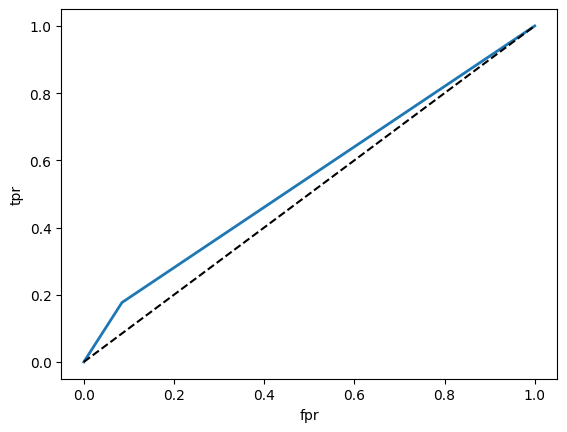

In [50]:
fpr, tpr, thresholds = roc_curve(test_y, pred_y)
auc = roc_auc_score(test_y, pred_y)
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
plt.xlabel('fpr')
plt.ylabel('tpr')
print(f'auc:{auc}')